# Import Essential Libraries

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import seaborn as sns
from sklearn.model_selection  import train_test_split,GridSearchCV,cross_val_score
from sklearn.pipeline  import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder,StandardScaler

import warnings
warnings.filterwarnings('ignore',category=FutureWarning)


# Load the Data

In [2]:
data_path = '/home/talha/Projects/student-score-project/datasets/student_data.csv'
student_data =  pd.read_csv(data_path)

In [3]:
# Head of dataset
print('='*12,'Head of Dataset','='*12)
print(student_data.head())
# Tail of data set
print('='*12,'Tail of Dataset','='*12)
print(student_data.tail())
# Info of Dataset
print('='*12,'Info of Dataset','='*12)
print(student_data.info())
# Missing values
print('='*12,'Missing values in Dataset','='*12)
print(student_data.isnull().sum())

============ Head of Dataset ============
   student_id  age  gender school_type parent_education  study_hours  \
0           1   14    male      public    post graduate          3.1   
1           2   18  female      public         graduate          3.7   
2           3   17  female     private    post graduate          7.9   
3           4   16   other      public      high school          1.1   
4           5   16  female      public      high school          1.3   

   attendance_percentage internet_access travel_time extra_activities  \
0                   84.3             yes     <15 min              yes   
1                   87.8             yes     >60 min               no   
2                   65.5              no     <15 min               no   
3                   58.1              no   15-30 min               no   
4                   61.0             yes   30-60 min              yes   

  study_method  math_score  science_score  english_score  overall_score  \
0        no

# Exploratory Data Analysis (EDA)

Distribution of Final Grades

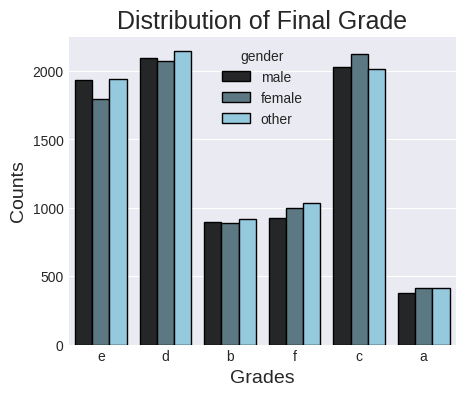

In [4]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
#  Distrubutive of final grade
plt.figure(figsize = (5,4))

sns.countplot(data= student_data,x= "final_grade", hue="gender", color='skyblue', edgecolor='black')
plt.title('Distribution of Final Grade',fontsize=18)
plt.xlabel('Grades',fontsize=14)
plt.ylabel('Counts',fontsize=14)
# plt.xticks(rotation=1)
plt.show()



 Correlation Graph

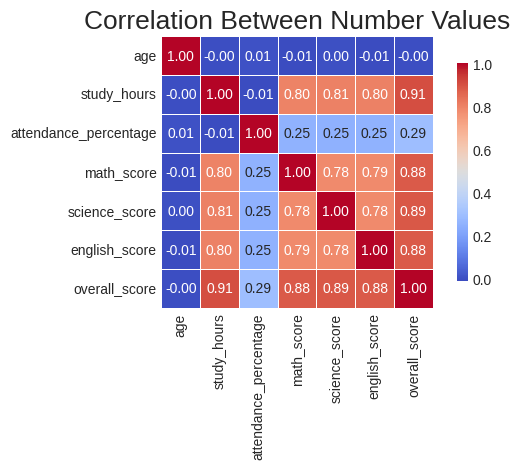

In [5]:
numerical_col = student_data.select_dtypes(exclude='object').drop('student_id',axis=1)
corr = numerical_col.corr()
sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt='.2f',
            square=True,
            linewidth=0.5,
            cbar_kws={'shrink':0.8})
plt.title('Correlation Between Number Values',fontsize=19 )
plt.tight_layout()
plt.show()

Subjects Wise Comparison of Scores

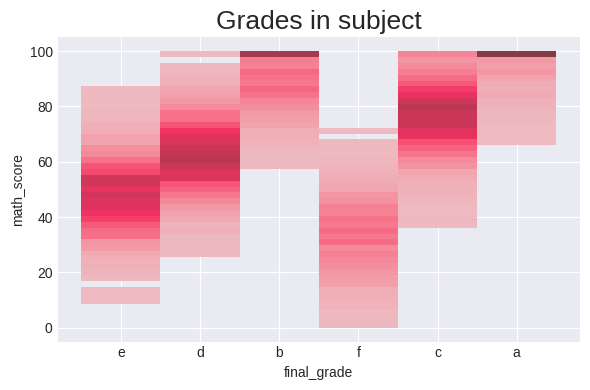

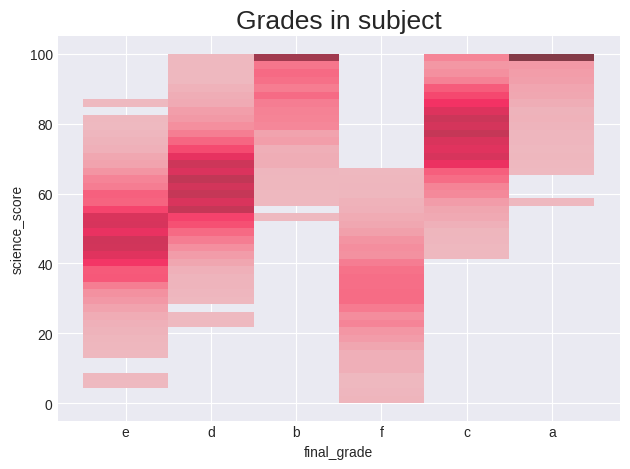

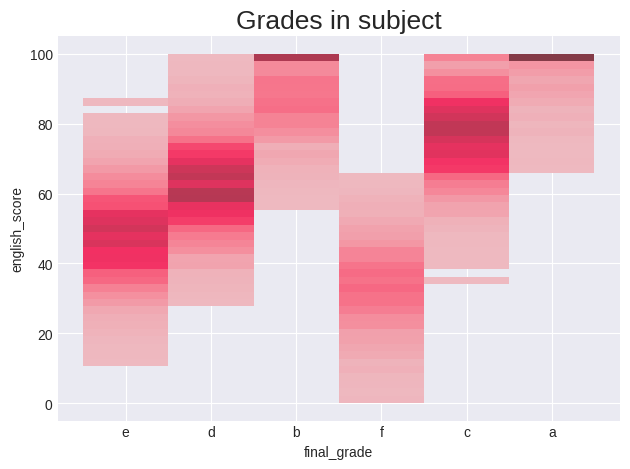

In [6]:
subject_col = ['math_score','science_score','english_score']

plt.figure(figsize=(6,4))

for i,subject in enumerate(subject_col):
   # plt.subplot(1,3,i+1)
    sns.histplot(data=student_data,x='final_grade',y=subject,linewidth=0.5)
    plt.title('Grades in subject',fontsize= 19)
    plt.tight_layout()
    plt.show()

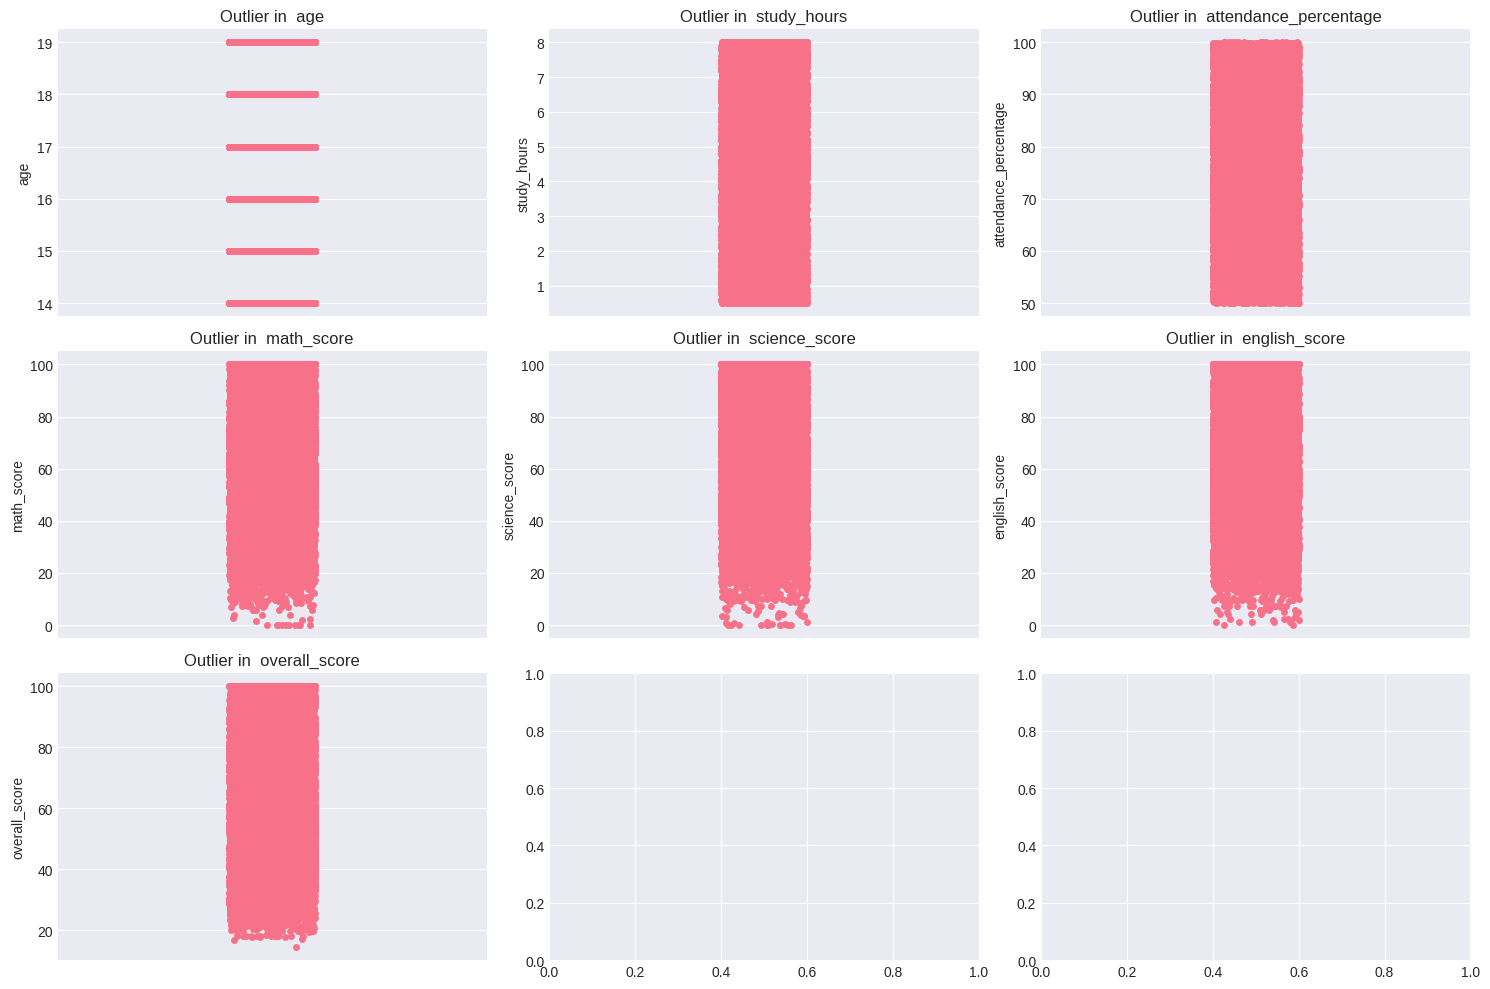

<Figure size 640x480 with 0 Axes>

In [7]:
fig ,axes = plt.subplots(3,3,figsize=(15,10))
axes= axes.flatten()
for i,subject in enumerate(numerical_col):
    
    sns.stripplot(y=student_data[subject], ax=axes[i])
    axes[i].set_title(f'Outlier in  {subject}')
plt.tight_layout()
plt.show()
# for hide the extra plots
for j in range(i+1,len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

# Feature Engineering Strategy

In [8]:
# Average marks column 
student_data['avg_subject_score'] = (student_data['science_score']+student_data['english_score']+student_data['math_score'])/3
# Score Variance
student_data['score_variance'] = student_data[['math_score','science_score','english_score']].var(axis=1)
student_data['study_efficiency'] = student_data['overall_score']/student_data['study_hours']


# Transformation

In [9]:
print(student_data.columns)
student_data.info()

Index(['student_id', 'age', 'gender', 'school_type', 'parent_education',
       'study_hours', 'attendance_percentage', 'internet_access',
       'travel_time', 'extra_activities', 'study_method', 'math_score',
       'science_score', 'english_score', 'overall_score', 'final_grade',
       'avg_subject_score', 'score_variance', 'study_efficiency'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             25000 non-null  int64  
 1   age                    25000 non-null  int64  
 2   gender                 25000 non-null  object 
 3   school_type            25000 non-null  object 
 4   parent_education       25000 non-null  object 
 5   study_hours            25000 non-null  float64
 6   attendance_percentage  25000 non-null  float64
 7   internet_access        25000 non-null  object

In [10]:
nominal_columns = [
    'gender',              # male/female/other
    'school_type',         # public/private
    'internet_access',     # yes/no
    'extra_activities'     # yes/no
]
ordinal_columns = [
    'parent_education',    # no formal < high school < diploma < graduate < post graduate < phd
    'travel_time',         # <15min < 15-30min < 30-60min < >60min
    'study_method'         # notes < textbook < mixed < coaching < group study (based on effectiveness)
]
numerical_columns = ['age','study_hours','attendance_percentage','overall_score','score_variance','study_efficiency']  # For classification


In [11]:
# Give order the cloumns
parent_education_order = ['no formal','high school','diploma','graduate','post graduate','phd']
travel_time_order = ['<15min','15-30min','30-60min','>60min']
study_method_order = ['notes','textbook','mixed','coaching','group study','online videos']

In [16]:
coulmn_transform = ColumnTransformer(
    transformers=[
        #Nominal Columns
        ('nominal',
        Pipeline([
            ('encoder',OneHotEncoder(drop='first',sparse_output=False,handle_unknown='ignore')),
    ]),nominal_columns),
    #Ordinal Cloumns
    ('ordinal',Pipeline([OrdinalEncoder(categories=[
        parent_education_order,
        travel_time_order,
        study_method_order])
        ]),ordinal_columns),
    #Numerical columns
    ('numerical',Pipeline([
        ('scaler',StandardScaler())
    ]),
    numerical_columns),
    ],
    remainder='drop',
    verbose_feature_names_out=False
)